In [1]:
# from BiSSGLc import BiSSGL
import BiSSGL as BiSSGL
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns  # optional, for nicer heatmaps


def plot_matrices(U, V, main1="Latent Matrix A", main2="Latent Matrix B"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.heatmap(U, ax=axes[0], cmap="viridis", cbar=True)
    axes[0].set_title(main1)

    sns.heatmap(V, ax=axes[1], cmap="viridis", cbar=True)
    axes[1].set_title(main2)

    plt.tight_layout()
    plt.show()

### Simulation setting 1:

- Modified from: M. Burkina, et. al. Inductive Matrix Completion with Feature Selection. 
- The latent matrix is $\mathbf{M}=\mathbf{X U^*\left(Y V^*\right)^{\top}}+\varepsilon$, where $\varepsilon \sim \mathcal{N}(0,0.005)$. 
- The side-channel features $\mathbf{X}$ and $\mathbf{Y}$ are independent random Gaussian matrices of respective dimensions $n_1 \times d$ and $n_2 \times d$ from $\mathcal{N}(0,0.05)$, where $n_1=800, n_2=1600$, and $d$ is varying. 
- The true values of $\mathbf{U}^*$ and $\mathbf{V}^*$ are specified by the first $k=25$ columns of the $d \times d$ identity matrix, thereby making the true number $d^*$ of informative side features equal to $k$. 
- The binary matrix $\mathbf{Y}$ used $0.5$ as the cutoff threshold. 

In [17]:
# This is new simulation setting for the feature selection:
I = 800
J = 1600
d = d1 = d2 = 100
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.52).astype(int)
# Y_true = np.random.binomial(n=1, p=Pr, size=(I, J))

sparsity = 0.5
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

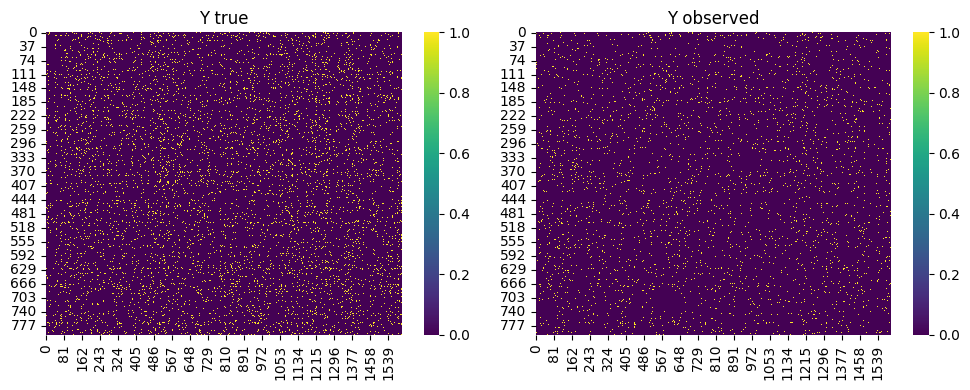

In [18]:
plot_matrices(Y_true, Y, "Y true", "Y observed")

In [19]:
# This is new simulation setting for the feature selection:
I = 400
J = 600
d = d1 = d2 = 50
K = K1 = K2 = 25

U = np.random.normal(0, np.sqrt(0.01), size=(I, d1))
U_true = U[:, :K1]
V = np.random.normal(0, np.sqrt(0.01), size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

Pr = expit(U_true @ A_true @ B_true.T @ V_true.T)
Y_true = (Pr > 0.5).astype(int)

sparsity = 0.1
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

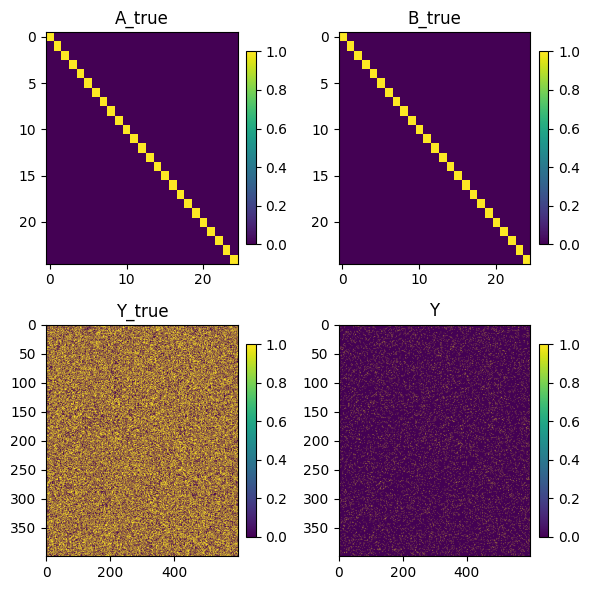

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(6, 6))

axes[0, 0].imshow(A_true, aspect="auto", cmap="viridis")
axes[0, 0].set_title("A_true")
plt.colorbar(axes[0, 0].images[0], ax=axes[0, 0], fraction=0.046, pad=0.04)

axes[0, 1].imshow(B_true, aspect="auto", cmap="viridis")
axes[0, 1].set_title("B_true")
plt.colorbar(axes[0, 1].images[0], ax=axes[0, 1], fraction=0.046, pad=0.04)

axes[1, 0].imshow(Y_true, aspect="auto", cmap="viridis")
axes[1, 0].set_title("Y_true")
plt.colorbar(axes[1, 0].images[0], ax=axes[1, 0], fraction=0.046, pad=0.04)

axes[1, 1].imshow(Y, aspect="auto", cmap="viridis")
axes[1, 1].set_title("Y")
plt.colorbar(axes[1, 1].images[0], ax=axes[1, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [21]:
A = np.zeros((d1, K))
A[range(K)] = A_true
A[K:] = np.random.normal(size=A[K:].shape) / 10
Ainput = A.copy()

B = np.zeros((d2, K))
B[range(K)] = B_true
B[K:] = np.random.normal(size=B[K:].shape) / 10
Binput = B.copy()

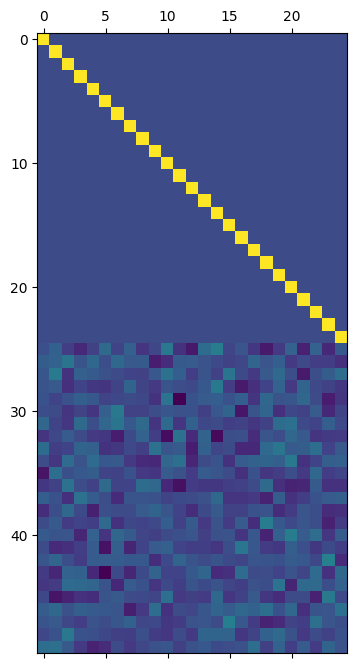

In [22]:
plt.matshow(Ainput)
# print(Ainput)

In [ ]:
model = BiSSGL(
    Y=Y,
    U=U,
    V=V,
    alpha=1 / K,
    beta=1,
    tilde_alpha=1 / K,
    K=K,
    max_iter=1000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

TypeError: 'module' object is not callable

In [24]:
est_mu, est_A, est_B, logLik = model.optimization()

NameError: name 'model' is not defined

In [33]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y,
    U=U,
    V=V,
    xi=1,
    eta=0.0001,
    tilde_lambda0=10,
    tilde_lambda1=1,
    tilde_alpha=1 / K,
    tilde_beta=1,
    lambda0=10,
    lambda1=1,
    alpha=1 / K,
    beta=1,
    K=K,
    max_iter=1000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

Finished with iterations of 999


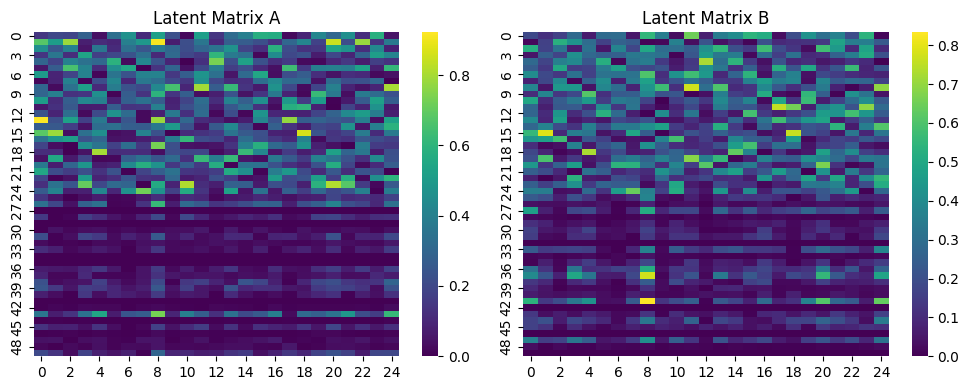

In [34]:
plot_matrices(np.abs(est_A), np.abs(est_B))

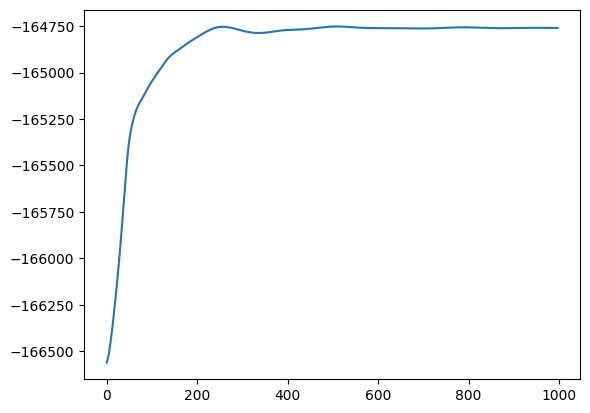

In [35]:
plt.plot(range(len(logLik)), logLik)

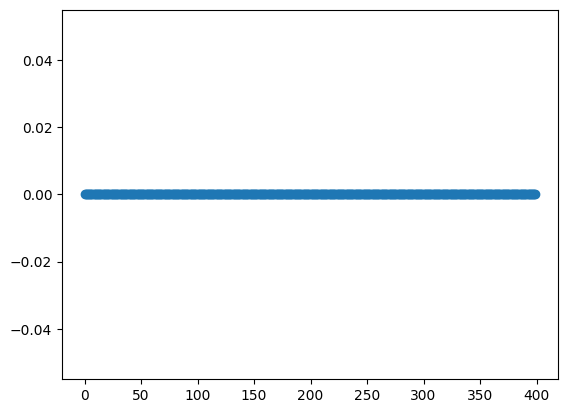

In [36]:
plt.plot(est_mu, marker="o")

<StemContainer object of 3 artists>

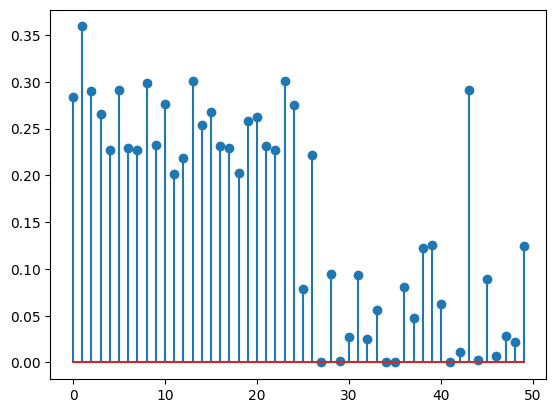

In [37]:
plt.stem(np.abs(est_A).mean(axis=1))

In [38]:
est_pr = expit(U @ est_A @ est_B.T @ V.T)
est_pr_masked = est_pr[masked_indices[:, 0], masked_indices[:, 1]]
y_test = Y_masked
y_score = est_pr_masked

In [39]:
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import auc


# Data to plot precision - recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.7740941963875307


In [40]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_tpr_fpr = auc(tpr, 1 - fpr)
print(auc_tpr_fpr)

print(roc_auc_score(y_test, y_score))

0.7947211151206555
0.7947211151206555


### Simulation setting 2:

- Modified from: Mark A. Davenport, et. al. 1-Bit matrix completion. This paper didn't considered side information. 
- The target matrix is a random $d \times d$ matrix $\mathbf{M}$ with rank $r$ by forming $\mathbf{M}=\mathbf{M}_1 \mathbf{M}_2^\top$ where $\mathbf{M}_1$ and $\mathbf{M}_2$ are $d \times r$ matrices with entries drawn i.i.d. from a uniform distribution on $\left[-\frac{1}{2}, \frac{1}{2}\right]$. 
- The matrix is then scaled so that $\|\mathbf{M}\|_{\infty}=1$. (Skipped). 
- We obtained 1-bit observations by adding Gaussian noise of variance $\sigma^2$ and recording the sign of the resulting value.


In [ ]:
# This is new simulation setting for the feature selection:
I = 500
J = 500
d = d1 = d2 = 50
K = K1 = K2 = 25

U = np.random.uniform(-0.5, 0.5, size=(I, d1))
U_true = U[:, :K1]
V = np.random.uniform(-0.5, 0.5, size=(J, d2))
V_true = V[:, :K2]
A_true = np.eye(K1)
B_true = np.eye(K2)

error = np.random.normal(0, 0.1, size=(I, J))
Y_true = (np.sign(U_true @ A_true @ B_true.T @ V_true.T + error) > 0).astype(int)

sparsity = 0.15
index = np.array(np.meshgrid(np.arange(I), np.arange(J))).T.reshape(-1, 2)
masked_indices = index[
    np.random.choice(index.shape[0], size=int((1 - sparsity) * I * J), replace=False)
]
Y_masked = Y_true[masked_indices[:, 0], masked_indices[:, 1]]
Y = Y_true.copy()
Y[masked_indices[:, 0], masked_indices[:, 1]] = 0

[[1 0 0 ... 1 0 0]
 [1 1 1 ... 1 0 1]
 [1 0 0 ... 0 0 1]
 ...
 [1 1 0 ... 1 0 1]
 [0 1 1 ... 1 0 0]
 [0 1 0 ... 0 1 1]]


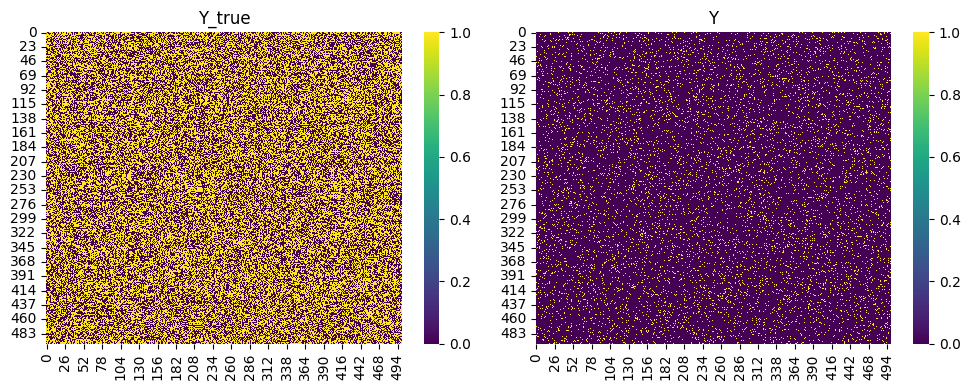

In [185]:
print(Y_true)
plot_matrices(Y_true, Y, "Y_true", "Y")

In [ ]:
est_mu, est_A, est_B, logLik = BiSSGL.optimization(
    Y,
    U=U,
    V=V,
    xi=2,
    eta=0.0001,
    tilde_lambda0=5,
    tilde_lambda1=1,
    tilde_alpha=1 / K,
    tilde_beta=1,
    lambda0=5,
    lambda1=1,
    alpha=1 / K,
    beta=1,
    K=K,
    max_iter=5000,
    tol=1e-5,
    # A=Ainput,
    # B=Binput,
)

[-5.39218944e+01  7.85462465e+01  3.84561559e+02  1.15372341e+01
  7.68888686e+01 -1.72549201e+02  6.81031248e+02 -4.64135078e+02
  1.07584521e+02  1.99850089e+02  9.00335211e+01 -8.29640944e+01
 -9.94577116e+01  2.98821632e+01 -2.78396605e+02  2.66567249e+02
 -2.88189249e+01 -1.64048426e+02 -1.20182767e+02 -4.07891242e+01
  2.92232604e-01  2.20474057e+02  2.28859523e+02 -3.57211761e+02
  1.76691405e+02]
[-177.92785045 -212.75292357 -484.53659244  -45.0015317    65.57116162
 -385.46783572 -274.08509726 -174.72072831  -12.97227874 -105.38751032
  348.70949411  447.75534581   -2.78530642   -9.2904904   162.54321205
  -67.39584398 -110.75650561   76.78408554  105.97520922 -290.02651914
 -449.92213921 -377.04611429 -182.09517852  574.45317418 -373.27141617]
[ -55.97611409   59.41477574  301.45670484   -4.08664912   41.6333421
 -170.8469106   597.62219795 -412.58753629   80.1399548   172.99196501
   94.65421726  -71.83452714 -102.39394566   22.09337687 -224.37991133
  222.64348103  -20.7183

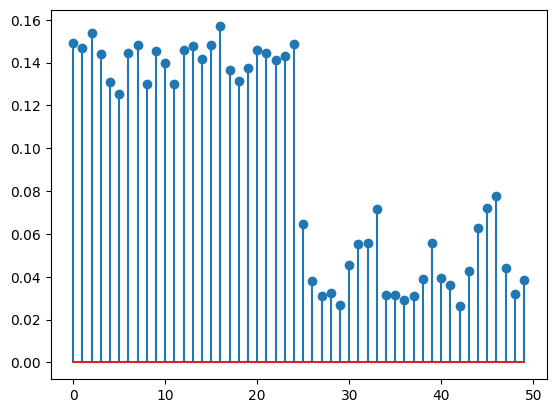

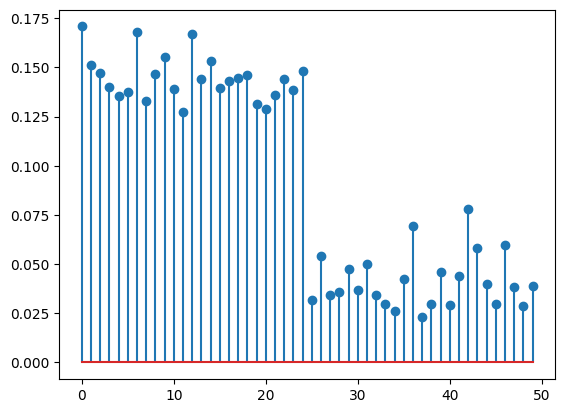

In [190]:
plt.stem(np.abs(est_A).mean(axis=1))
plt.show()
plt.stem(np.abs(est_B).mean(axis=1))
plt.show()

In [191]:
est_pr = expit(U @ est_A @ est_B.T @ V.T)
est_pr_masked = est_pr[masked_indices[:, 0], masked_indices[:, 1]]
y_test = Y_masked
y_score = est_pr_masked
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.metrics import auc


# Data to plot precision - recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_score)
# Use AUC function to calculate the area under the curve of precision recall curve
auc_precision_recall = auc(recall, precision)
print(auc_precision_recall)

0.9038344939833355


In [192]:
fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc_tpr_fpr = auc(tpr, 1 - fpr)
print(auc_tpr_fpr)

print(roc_auc_score(y_test, y_score))

0.9025656480443099
0.9025656480443098


### Plans:

1. Algorithm modification
- (Option 1): add 10-fold CV inside the algorithm. 
- (Option 2): add $\lambda$ ladders similar as SSLB. 

2. Competing methods:
- SGIMC: https://github.com/premolab/SGIMC (2018 - 2021, Python)
- IMC: without side information selection. 
- DRIMC: (R)
- NRLMF (Python, used in DRIMC, can be replaced with other more recent methods.)


2. Simulation:
- Two settings with different distributions.
- Add side information noise. 